# Exploratory Data Analysis (EDA) – Credit Risk Engine

## SECTION 0: PROJECT INTRODUCTION

In [3]:
## Project: Credit Risk Engine

## Dataset: Taiwan Credit Default Risk (30,000 clients)

## Objective: Predict default_payment_next_month

## Target: 0 = No Default, 1 = Default

## Guiding Question: What factors best explain the risk of default in credit clients?

## SECTION 1: PREPARATION

### 1.1 Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 1.2 Dataset Loading

In [5]:
df = pd.read_csv("../data/raw/credit_card_default.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 1.3 Data Quality Check  

In [6]:
df.info()
print("Missing values:\n", df.isnull().sum()) 
print("Duplicated rows:", df.duplicated().sum()) 
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 1.4 Variable Dictionary  

In [7]:
# About the dataset:
# This dataset was collected to predict the probability of credit card default,
# which is essential for risk management in the financial sector.
# It contains information on credit card clients in Taiwan, including
# socio-demographic details, credit limits, and six months of payment history.
# The dataset was originally compiled for research comparing the predictive
# accuracy of six data mining methods, where artificial neural networks
# achieved the highest accuracy in estimating default probability.
# Monetary amounts are expressed in NT$ (New Taiwan Dollars).

# ------------------------------------------------------------
# Feature Groups and Attributes
# ------------------------------------------------------------

# 1. Socio-demographic variables
# X2: SEX          -> Gender (1 = male, 2 = female)
# X3: EDUCATION    -> Education level (1 = postgraduate, 2 = university,
#                      3 = high school, 4 = others)
# X4: MARRIAGE     -> Marital status (1 = married, 2 = single, 3 = others)
# X5: AGE          -> Age in years

# 2. Financial variables
# X1: LIMIT_BAL    -> Credit limit (includes individual and family credit)
# X6–X11: PAY_0…PAY_6 -> Payment status history (from September 2005 to April 2005).
#                        Scale: -1 = payment on time, 0 = no delay,
#                        1 = one month delay, up to 9 = nine months or more delayed.

# 3. Statement amounts
# X12–X17: BILL_AMT1…BILL_AMT6 -> Bill statement amounts for six consecutive months
#                                 (September 2005 to April 2005).
# Continuous variables, measured in NT$.

# 4. Payment amounts
# X18–X23: PAY_AMT1…PAY_AMT6 -> Amounts paid in the previous six months
#                               (September 2005 to April 2005).
# Continuous variables, measured in NT$.

# 5. Target variable
# Y: default payment_next_month -> Binary response variable
#                                  0 = no default, 1 = default

# ------------------------------------------------------------
# Dataset Structure
# ------------------------------------------------------------
# - Total records: 30,000 clients
# - Total columns: 25 (23 explanatory variables + 1 ID + 1 target)
# - ID: Client identification number


### 1.5 Outlier Analysis

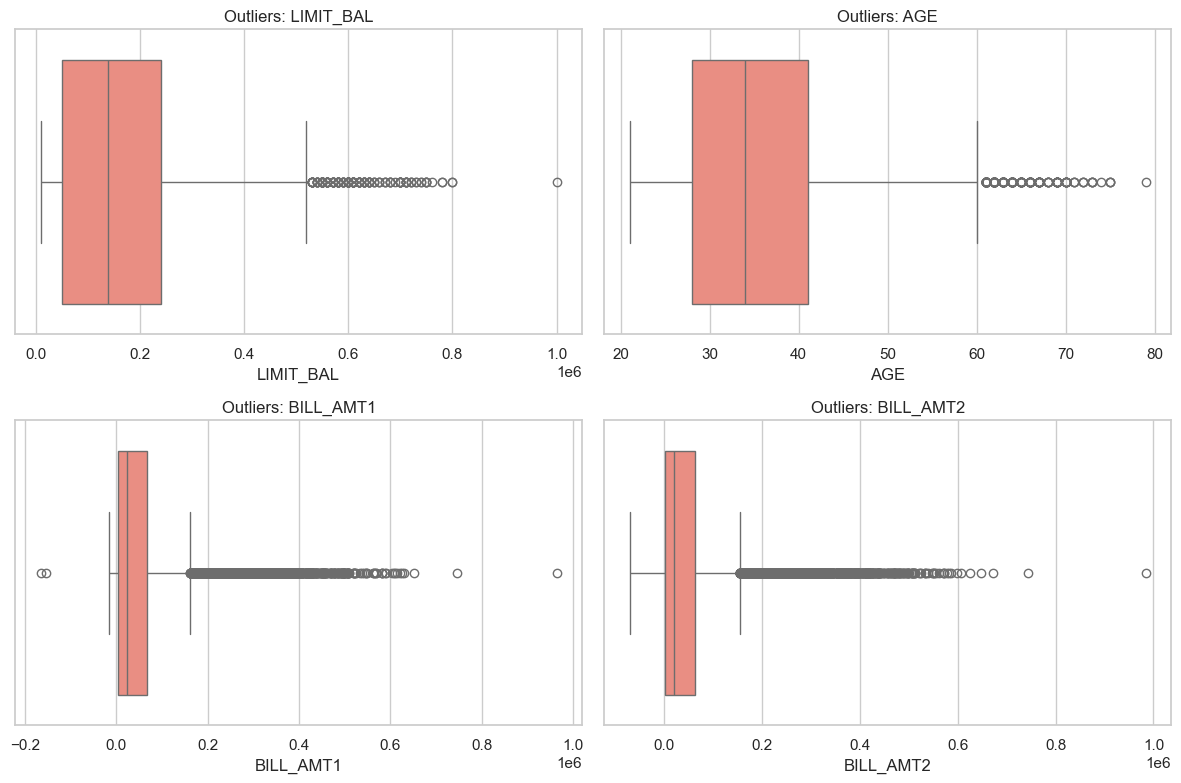

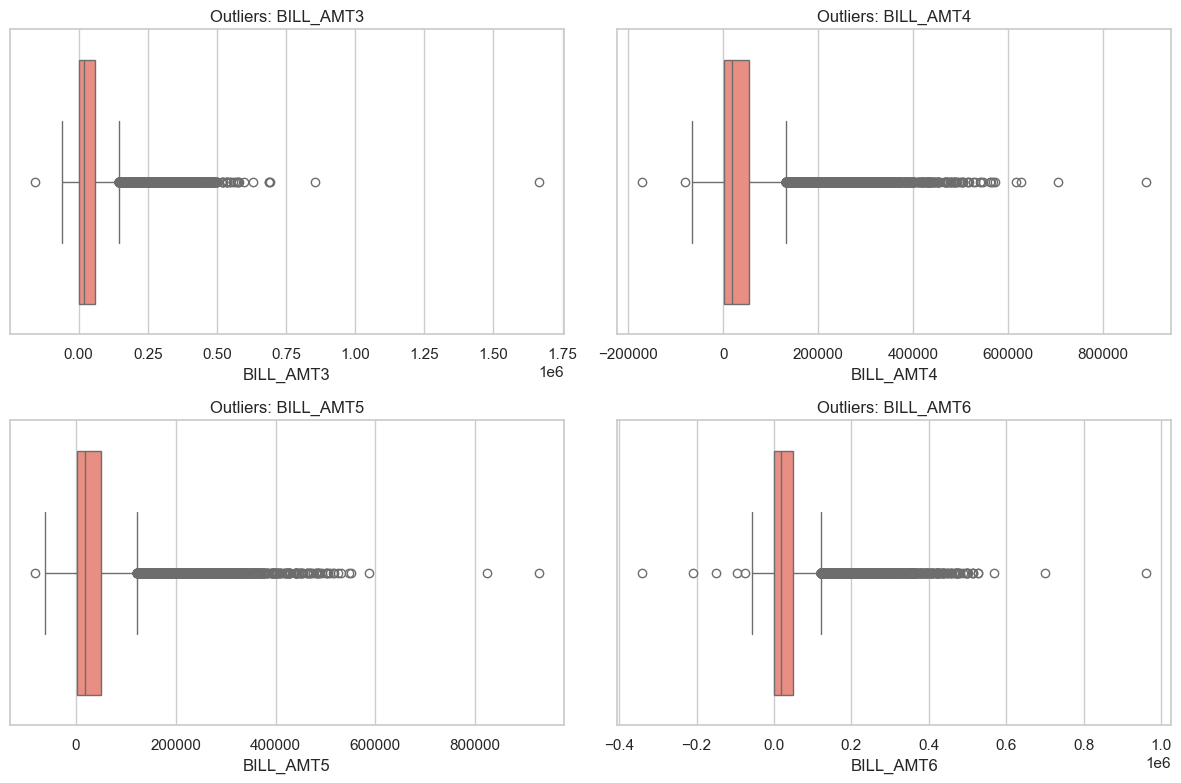

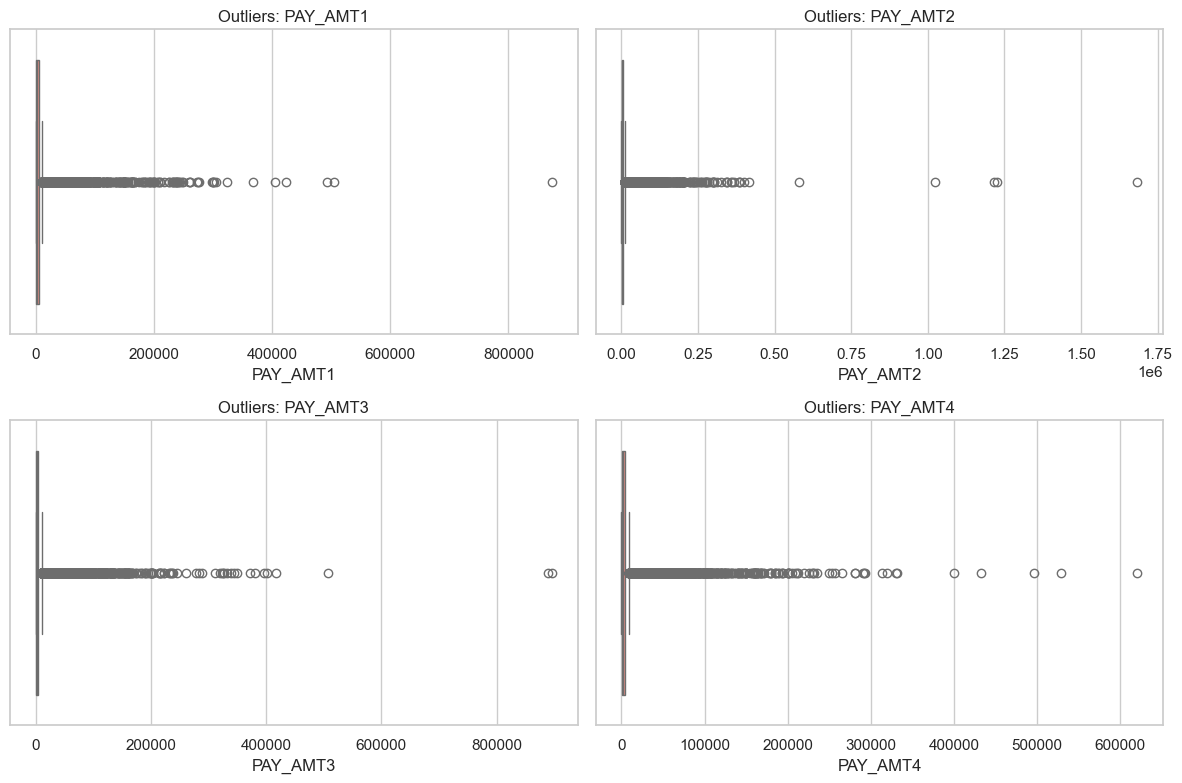

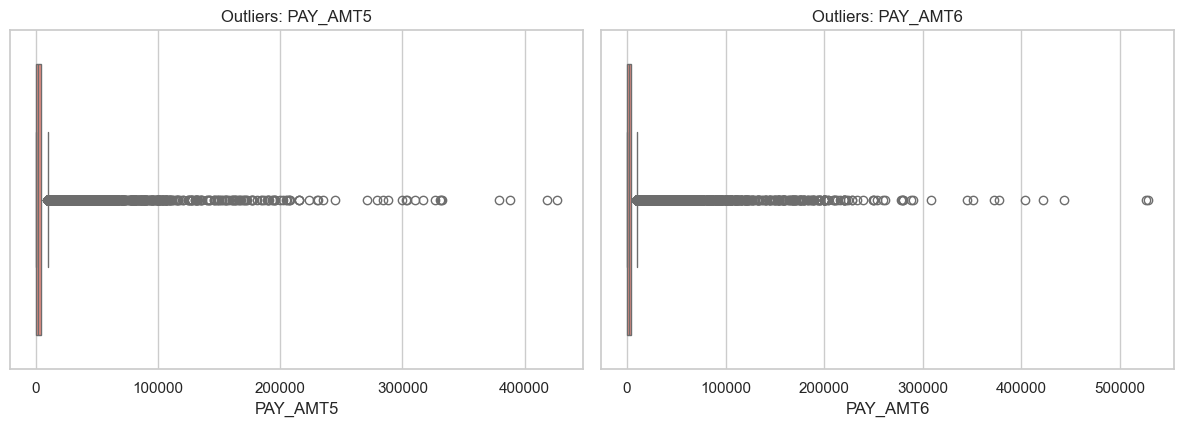

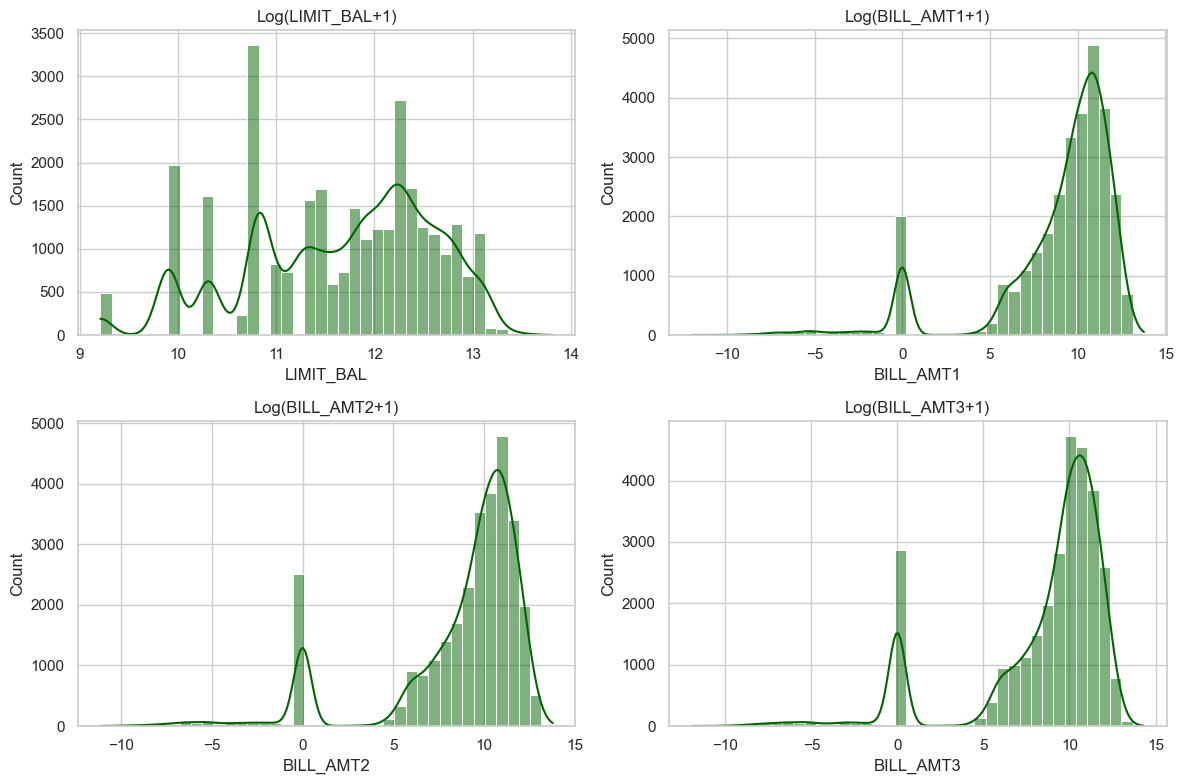

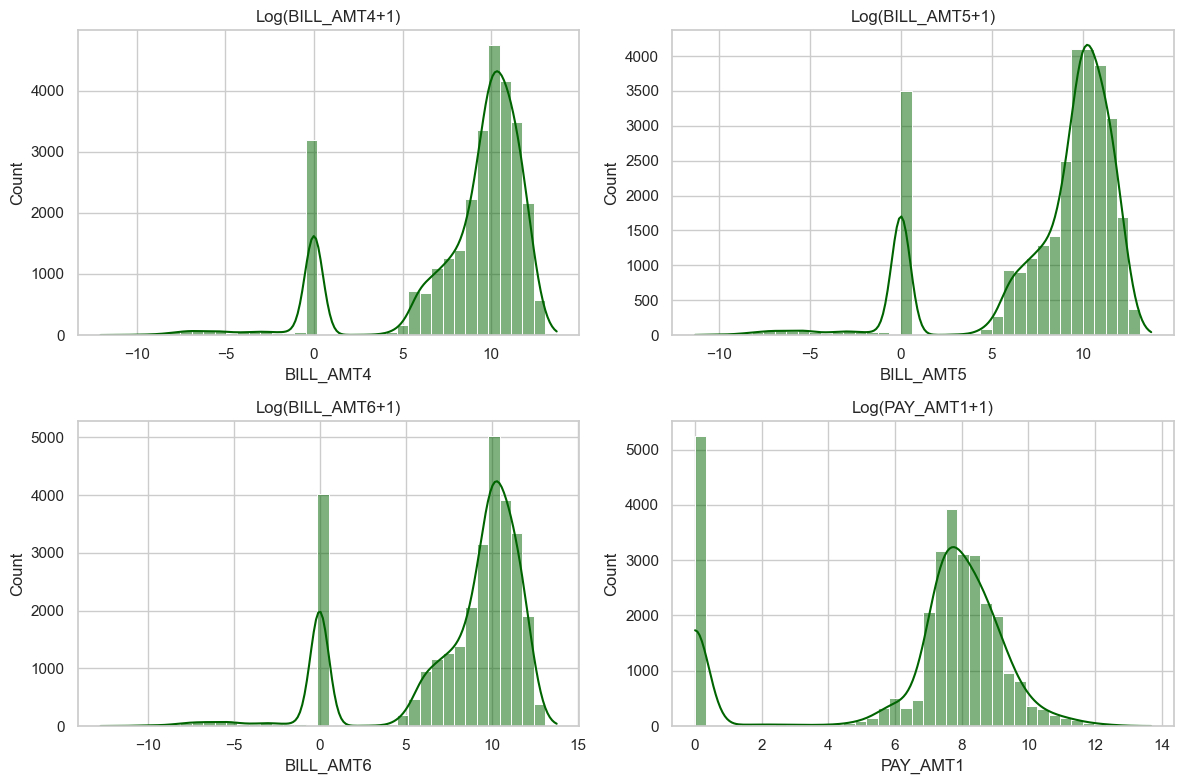

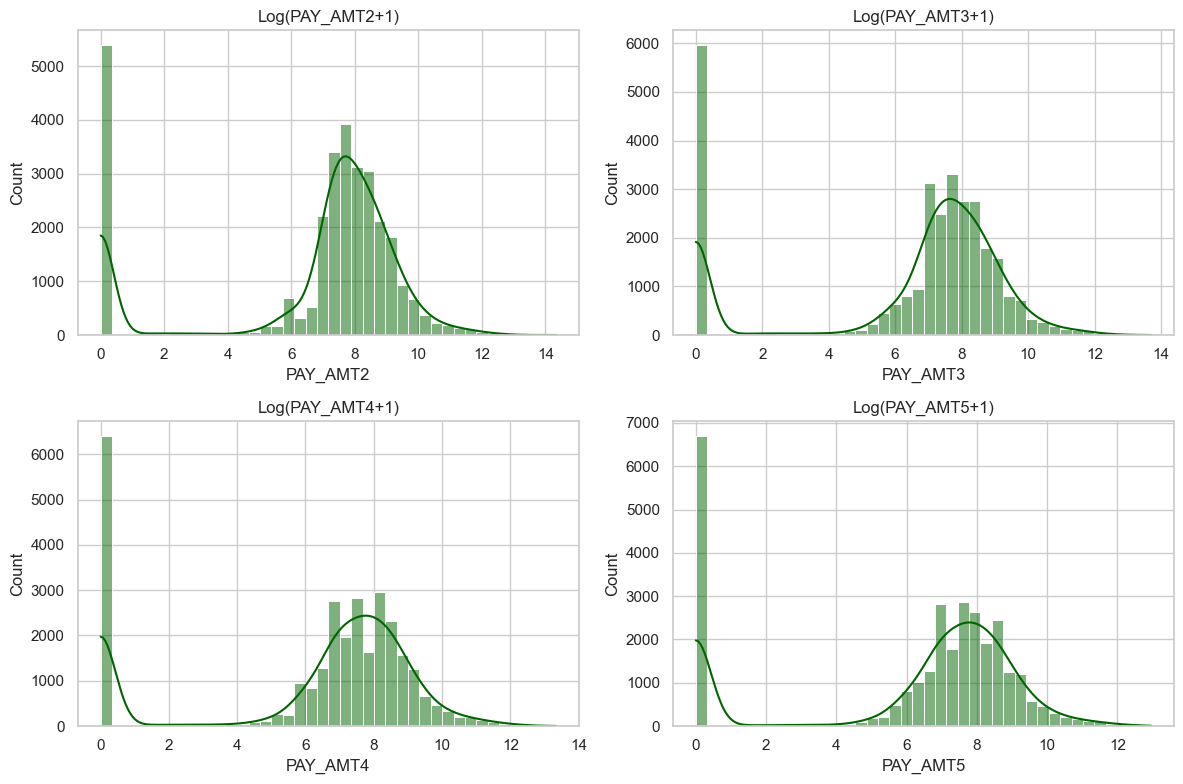

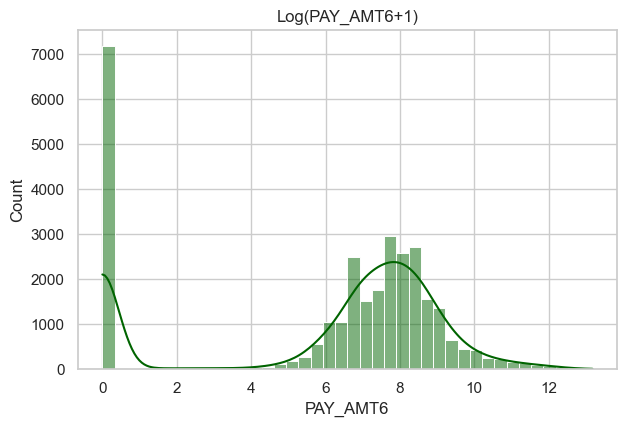

In [8]:
# Key variables
num_vars = ['LIMIT_BAL', 'AGE'] + \
           [f'BILL_AMT{i}' for i in range(1,7)] + \
           [f'PAY_AMT{i}' for i in range(1,7)]

def plot_grid(vars, transform=False):
    for i in range(0, len(vars), 4):
        subset = vars[i:i+4]
        fig, axes = plt.subplots(2, 2, figsize=(12,8))
        axes = axes.flatten()
        
        for j, col in enumerate(subset):
            if transform:
                sns.histplot(np.sign(df[col]) * np.log1p(np.abs(df[col])), bins=40, kde=True, ax=axes[j], color='darkgreen')
                axes[j].set_title(f'Log({col}+1)')
            else:
                sns.boxplot(x=df[col], ax=axes[j], color='salmon')
                axes[j].set_title(f'Outliers: {col}')
        
        # Hide empty subplots if subset < 4
        for k in range(len(subset), 4):
            axes[k].set_visible(False)
        
        plt.tight_layout()
        plt.show()

# 1. Grouped Boxplots (outlier detection)
plot_grid(num_vars, transform=False)

# 2. Grouped log-transformed histograms
log_vars = ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]
plot_grid(log_vars, transform=True)



## SECTION 2: UNIVARIATE ANALYSIS

### 2.1 Categorical Variables

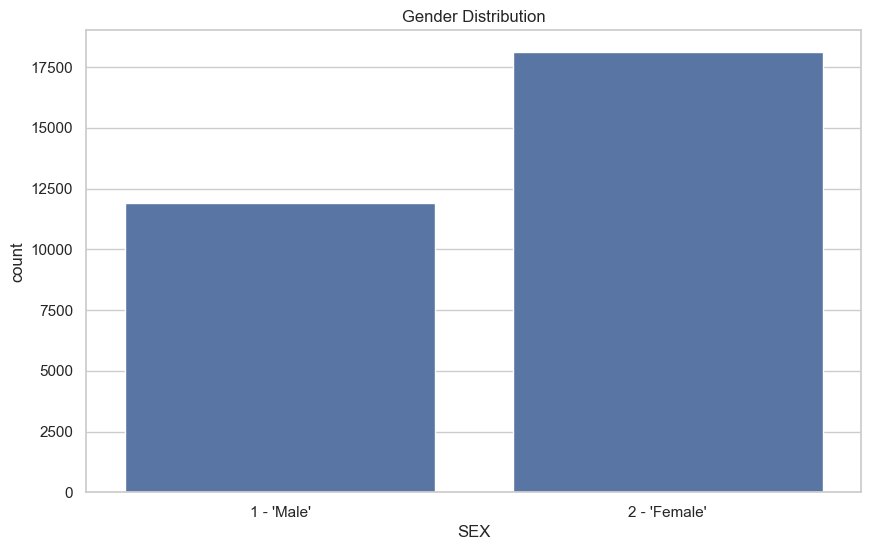

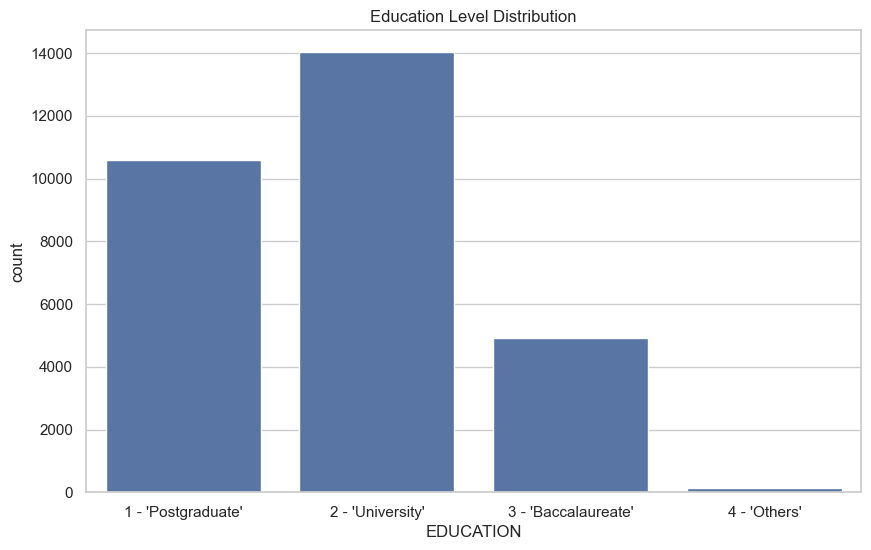

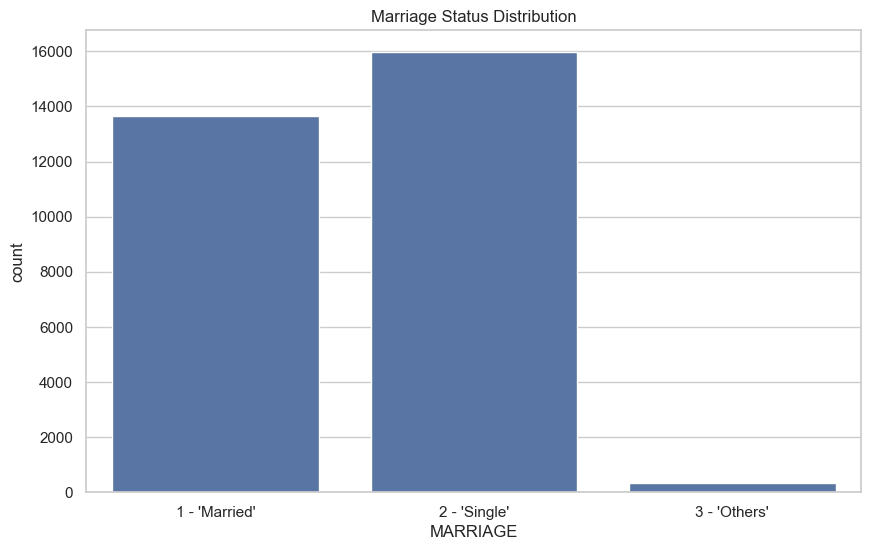

In [9]:
# --- Graph 1: SEX --- 
sns.countplot(x="SEX", data=df) 
plt.title("Gender Distribution") 
plt.xticks([0, 1], ["1 - 'Male'", "2 - 'Female'"])
plt.show()

 
# --- Graph 2: EDUCATION --- 
df_edu = df[df["EDUCATION"].isin([1, 2, 3, 4])]
sns.countplot(x="EDUCATION", data=df_edu, order=[1, 2, 3, 4])
plt.title("Education Level Distribution")
plt.xticks([0, 1, 2, 3], ["1 - 'Postgraduate'", "2 - 'University'", "3 - 'Baccalaureate'", "4 - 'Others'"])
plt.show()


# --- Graph 2: MARRIAGE --- 
df_mar = df[df["MARRIAGE"].isin([1, 2, 3])]
sns.countplot(x="MARRIAGE", data=df_mar, order=[1, 2, 3])
plt.title("Marriage Status Distribution")
plt.xticks([0, 1, 2], ["1 - 'Married'", "2 - 'Single'", "3 - 'Others'"])
plt.show()

### 2.2 Numeral Variables

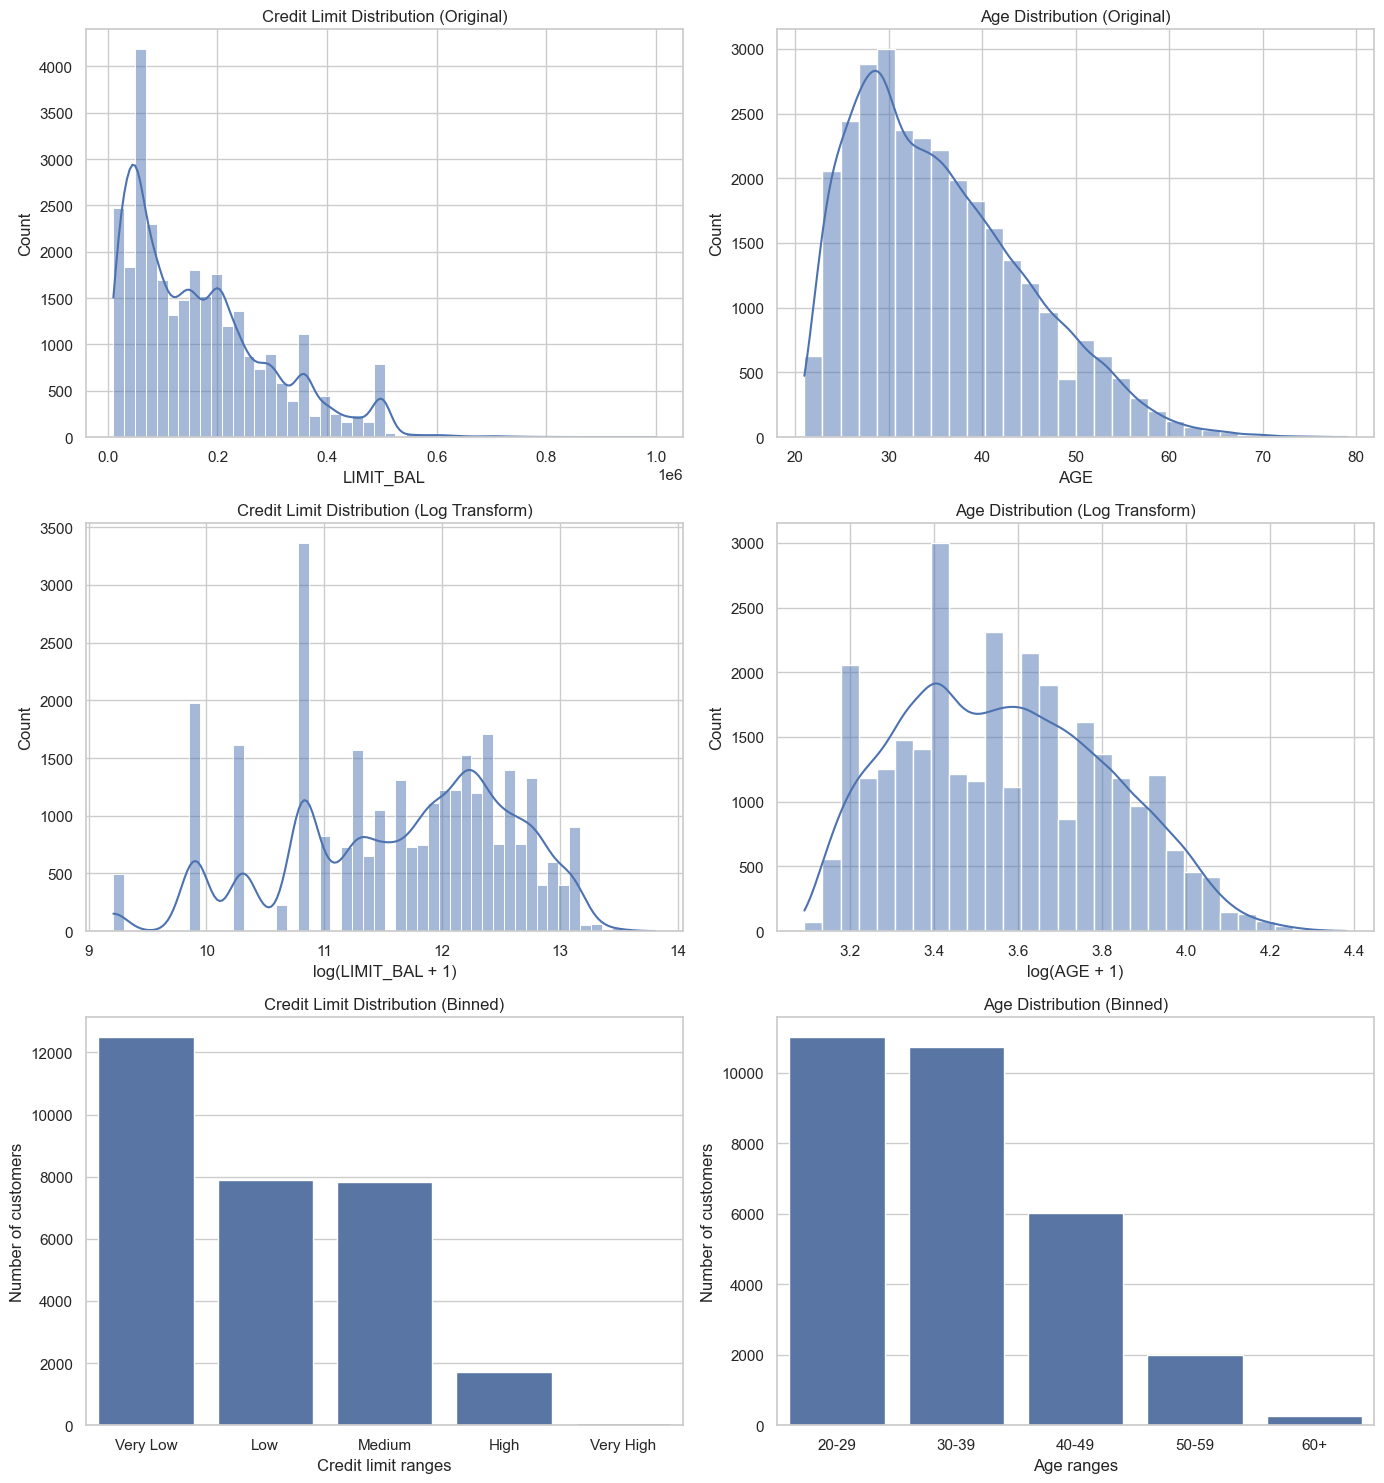

In [10]:
# Define bins para LIMIT_BAL y AGE 
bins_credit = [0, 100000, 200000, 400000, 600000, 1000000] 
# labels_credit = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"] 
labels_credit = ["Very Low", "Low", "Medium", "High", "Very High"]
df["LIMIT_BAL_BIN"] = pd.cut(df["LIMIT_BAL"], bins=bins_credit, labels=labels_credit)

bins_age = [20, 30, 40, 50, 60, 80] 
labels_age = ["20-29", "30-39", "40-49", "50-59", "60+"] 
df["AGE_BIN"] = pd.cut(df["AGE"], bins=bins_age, labels=labels_age)

# Create a shape with 2 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# --- Graphic 1: Original Credit Limit ---
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True, ax=axes[0,0]) 
axes[0,0].set_title("Credit Limit Distribution (Original)") 
axes[0,0].set_xlabel("LIMIT_BAL")


# --- Graphic 2: Original Age ---
sns.histplot(df["AGE"], bins=30, kde=True, ax=axes[0,1]) 
axes[0,1].set_title("Age Distribution (Original)") 
axes[0,1].set_xlabel("AGE")

# --- Graphic 3: Log Transform Credit Limit --- 
sns.histplot(np.log1p(df["LIMIT_BAL"]), bins=50, kde=True, ax=axes[1,0]) 
axes[1,0].set_title("Credit Limit Distribution (Log Transform)") 
axes[1,0].set_xlabel("log(LIMIT_BAL + 1)") 

# --- Graphic 4: Log Transform Age --- 
sns.histplot(np.log1p(df["AGE"]), bins=30, kde=True, ax=axes[1,1]) 
axes[1,1].set_title("Age Distribution (Log Transform)") 
axes[1,1].set_xlabel("log(AGE + 1)") 

# --- Graphic 5: Binning --- 
sns.countplot(x="LIMIT_BAL_BIN", data=df, ax=axes[2,0]) 
axes[2,0].set_title("Credit Limit Distribution (Binned)") 
axes[2,0].set_xlabel("Credit limit ranges") 
axes[2,0].set_ylabel("Number of customers") 

sns.countplot(x="AGE_BIN", data=df, ax=axes[2,1]) 
axes[2,1].set_title("Age Distribution (Binned)") 
axes[2,1].set_xlabel("Age ranges") 
axes[2,1].set_ylabel("Number of customers")

plt.tight_layout() 
plt.show()

### 2.3 Target variable (default/no default)  

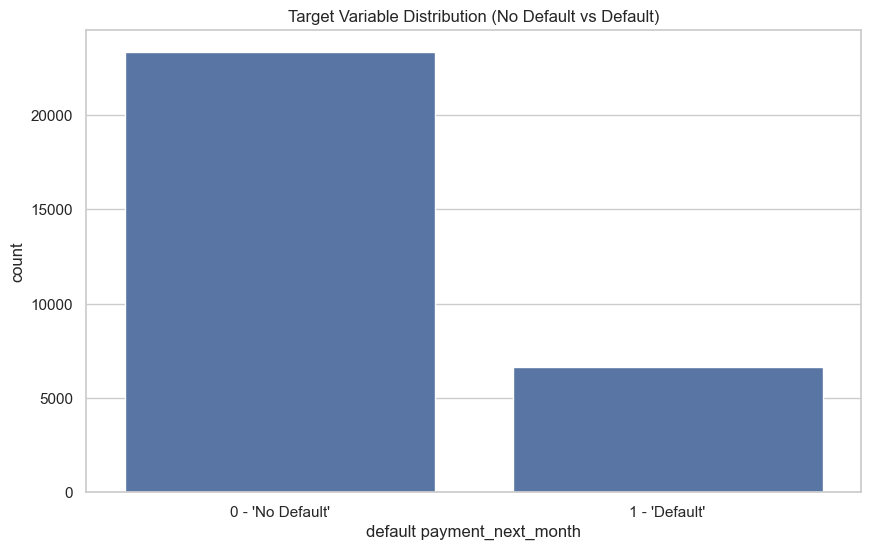

default payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [11]:
sns.countplot(x="default payment_next_month", data=df)
plt.title("Target Variable Distribution (No Default vs Default)")
plt.xticks([0, 1], ["0 - 'No Default'", "1 - 'Default'"])
plt.show()

df["default payment_next_month"].value_counts(normalize=True)

## SECTION 3: BIVARIATE ANALYSIS

### 3.1 Relationship Between Independent Variables and the Target

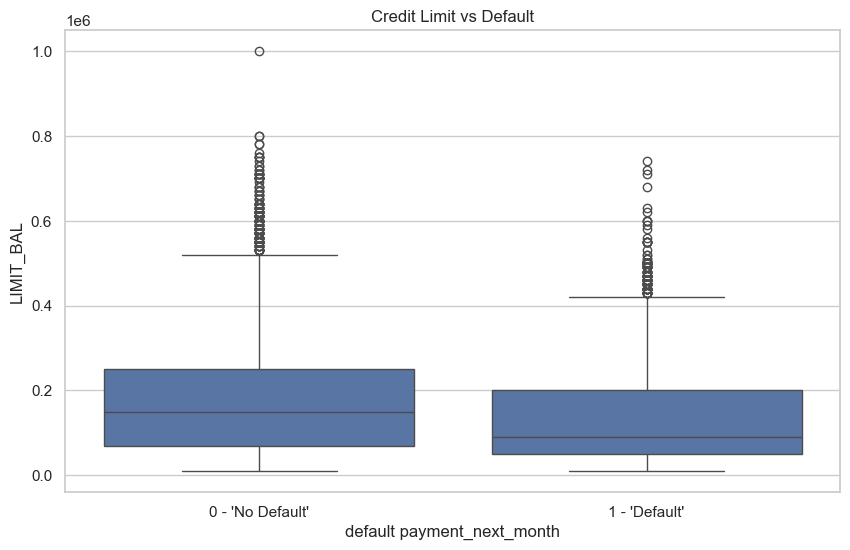

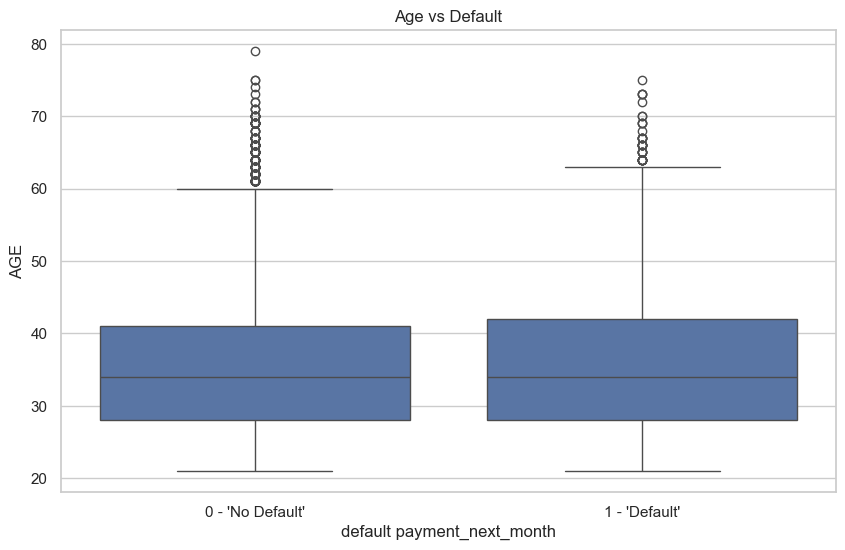

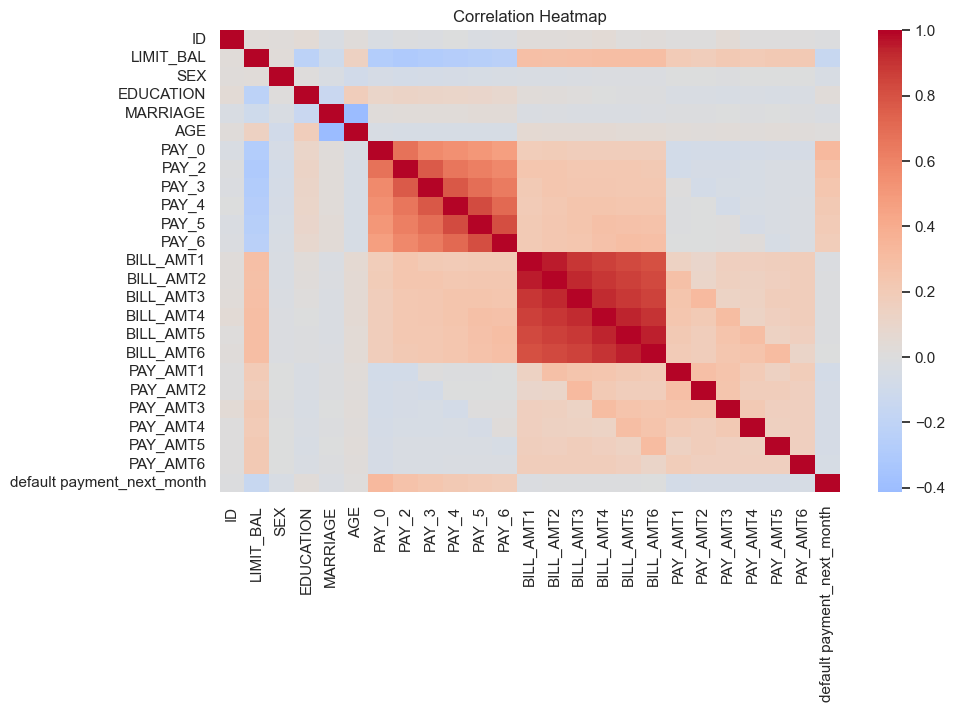

In [12]:
sns.boxplot(x="default payment_next_month", y="LIMIT_BAL", data=df) 
plt.title("Credit Limit vs Default") 
plt.xticks([0, 1], ["0 - 'No Default'", "1 - 'Default'"])
plt.show()
 
sns.boxplot(x="default payment_next_month", y="AGE", data=df) 
plt.title("Age vs Default") 
plt.xticks([0, 1], ["0 - 'No Default'", "1 - 'Default'"])
plt.show() 

corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## SECTION 4: PATTERNS AND FINANCIAL BEHAVIOR

### 4.1 Patterns and Hypotheses  

In [13]:
mar_default = pd.crosstab(df["MARRIAGE"], df["default payment_next_month"], normalize="index") 
print("Default rate by Marriage:\n", mar_default)

edu_default = pd.crosstab(df["EDUCATION"], df["default payment_next_month"], normalize="index") 
print("Default rate by Education:\n", edu_default) 

sex_default = pd.crosstab(df["SEX"], df["default payment_next_month"], normalize="index")
print("Default rate by Sex:\n", sex_default)

Default rate by Marriage:
 default payment_next_month         0         1
MARRIAGE                                      
0                           0.907407  0.092593
1                           0.765283  0.234717
2                           0.790717  0.209283
3                           0.739938  0.260062
Default rate by Education:
 default payment_next_month         0         1
EDUCATION                                     
0                           1.000000  0.000000
1                           0.807652  0.192348
2                           0.762651  0.237349
3                           0.748424  0.251576
4                           0.943089  0.056911
5                           0.935714  0.064286
6                           0.843137  0.156863
Default rate by Sex:
 default payment_next_month         0         1
SEX                                           
1                           0.758328  0.241672
2                           0.792237  0.207763


### 4.2 Risk Intersection Analysis  

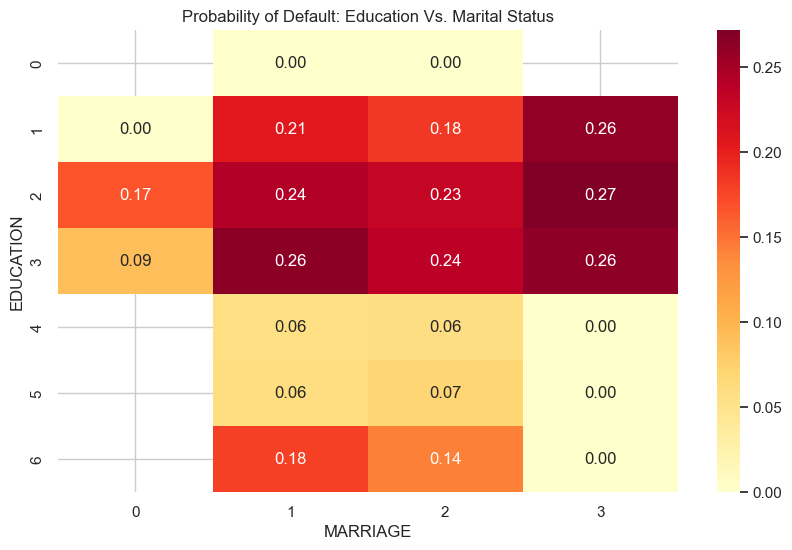

In [14]:
# We created a pivot table to see the cross-default rate
pivot_risk = df.pivot_table(index='EDUCATION', columns='MARRIAGE', 
                            values='default payment_next_month', aggfunc='mean')


plt.figure(figsize=(10, 6))
sns.heatmap(pivot_risk, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Probability of Default: Education Vs. Marital Status')
plt.show()

### 4.3 Financial Behavior Analysis  

#### 4.3.1 Impact of Payment Delay (PAY_0)  

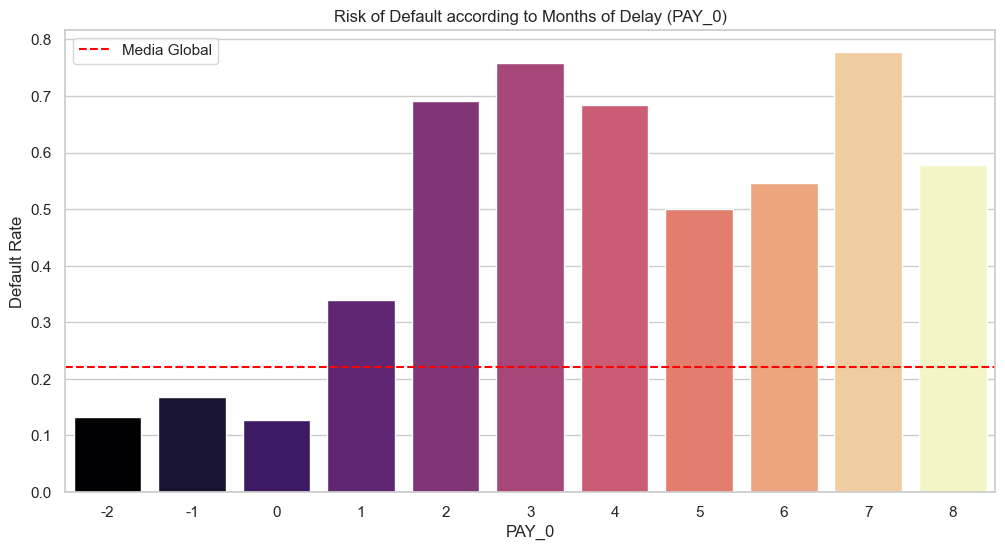

In [15]:
plt.figure(figsize=(12, 6))
# We calculate the default rate by PAY_0 category
pay_0_risk = df.groupby('PAY_0')['default payment_next_month'].mean()

sns.barplot(x=pay_0_risk.index, y=pay_0_risk.values, hue=pay_0_risk.index, palette="magma", legend=False)
plt.axhline(y=df['default payment_next_month'].mean(), color='red', linestyle='--', label='Media Global')
plt.title('Risk of Default according to Months of Delay (PAY_0)')
plt.ylabel('Default Rate')
plt.legend()
plt.show()

#### 4.3.2 Utilization Ratio (Debt / Limit)

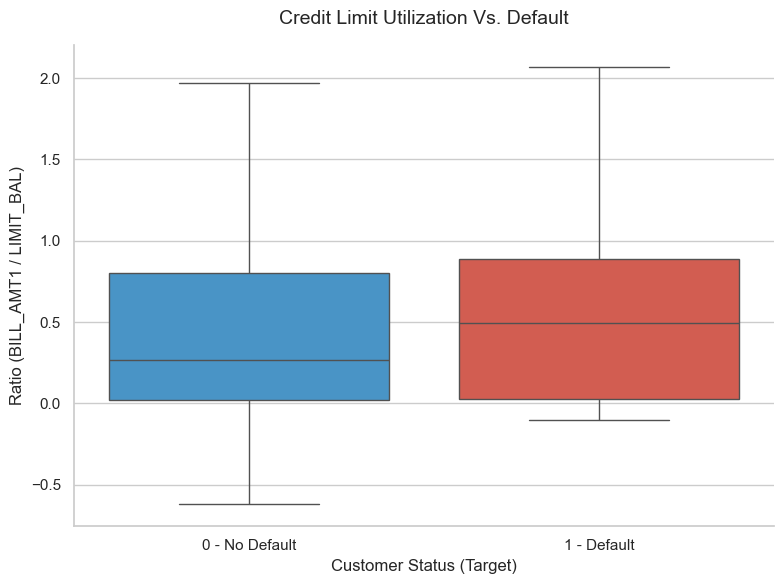

In [16]:
# We created the variable (Feature Engineering for the EDA)
df['UTILIZATION_1'] = df['BILL_AMT1'] / df['LIMIT_BAL']

plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df, x='default payment_next_month', y='UTILIZATION_1', 
                 hue='default payment_next_month', showfliers=False, palette=['#3498db', '#e74c3c'], legend=False)

plt.xticks(ticks=[0, 1], labels=['0 - No Default', '1 - Default'], fontsize=11)

plt.title('Credit Limit Utilization Vs. Default', fontsize=14, pad=15)
plt.xlabel('Customer Status (Target)', fontsize=12)
plt.ylabel('Ratio (BILL_AMT1 / LIMIT_BAL)', fontsize=12)

sns.despine() 
plt.tight_layout()
plt.show()

#### 4.3.3 Correlation in Billing Amounts  

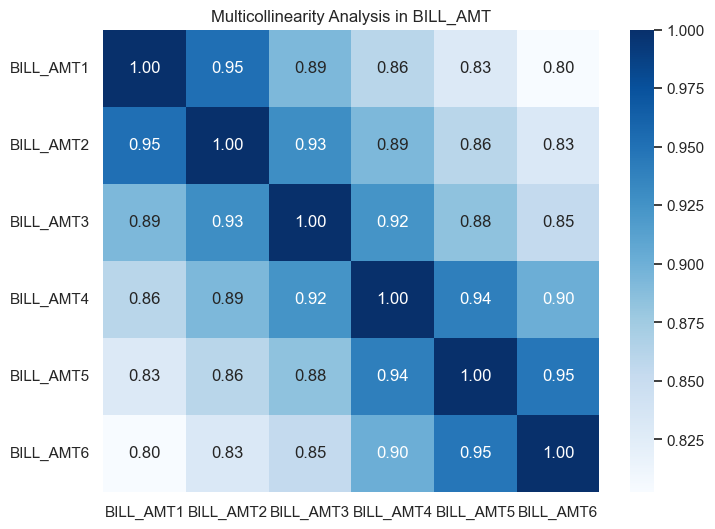

In [17]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
plt.figure(figsize=(8, 6))
sns.heatmap(df[bill_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Multicollinearity Analysis in BILL_AMT')
plt.show()

## SECTION 5: INSIGHTS AND KEY FINDING

### 5.1 Exploratory Analysis & Key Findings  

In [18]:
# 1. Class Balance
# The dataset shows a moderate imbalance:
# ~75% of clients are non-defaulters, while ~25% are defaulters.
# This implies that accuracy alone is misleading; metrics such as
# AUC, F1-score, and recall are more appropriate for evaluation.

# 2. Demographic Factors
# - Gender: Female clients tend to have slightly lower default rates than males.
# - Education: University and high-school educated clients show higher default rates
#   compared to postgraduate clients.
# - Marital Status: Single clients are more prone to default compared to married ones.

# 3. Financial Factors
# - Payment Delays (PAY_0...PAY_6): The strongest predictor of default.
#   Longer and more recent delays significantly increase default probability.
# - Credit Limit (LIMIT_BAL): Clients with lower credit limits are more likely to default,
#   while higher limits correlate with reduced risk.
# - Credit Utilization (BILL_AMT / LIMIT_BAL): High utilization ratios are strongly
#   associated with default risk.

# 4. Behavioral Patterns
# - Billing Amounts (BILL_AMT1–6): Highly correlated with each other, indicating redundancy
#   and potential multicollinearity.
# - Payment Amounts (PAY_AMT1–6): Extremely skewed distributions with many small payments
#   and a few very large ones. Log-transformations help stabilize these variables
#   and reveal clearer patterns.

# 5. Key Findings for Modeling
# - Most relevant predictors: PAY_0, LIMIT_BAL, credit utilization ratio,
#   EDUCATION, and MARRIAGE.
# - Financial behavior patterns are consistent: payment delays and high utilization
#   are critical signals of risk.
# - Class imbalance and variable redundancy must be addressed through techniques
#   such as resampling (SMOTE, undersampling) and feature selection.
